# Mamba Design

Designing Mamba architecture based on this [block diagram](https://www.ibm.com/think/topics/mamba-model). 


In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim

Before, we had to create our own custom tokenizer, based on each char in our vocab_size. We will no longer do this! Let's use a pre-trained tokenizer from **HuggingFace** with all the fun bells and whistles.

In [2]:
from transformers import AutoTokenizer # HuggingFace 

# mamba uses "EleutherAI/gpt-neox-20b" tokenizer
tokenizer_name = "EleutherAI/gpt-neox-20b"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
tokenizer.model_max_length = 2048 # max seq length of Mamba (example)
tokenizer.pad_token = tokenizer.eos_token # explicitly say when things end
test_input = "Hello world!"
tensor_input = tokenizer(test_input, return_tensors="pt")
print(tensor_input["input_ids"].shape) # 1 x L
print(tokenizer.decode(tensor_input["input_ids"][0]))
print(f"Vocab size: {tokenizer.vocab_size}")

/projectnb/epic-iarpa/willjdes/whiteboard_test/Tutorial_pt2/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([1, 3])
Hello world!
Vocab size: 50254


We will also test out the train-test split and get_batch standards in **HuggingFace**. Should be of good use to us long down the road when we want to quickly set these features up for our model of choice.

Make sure to have a good understanding of:
- Iterables vs Iterators (Native Python)
- Dataset vs DatasetDict (HF)
- Tensors (PT)
- Native collectibles (list, dict, set, etc.) 

In [3]:
from datasets import Dataset, load_dataset

# hardcoded set of strings (data)
# raw_data = {
#     "text": [
#         "PyTorch makes tensor math easy.",
#         "Hugging Face standardizes the data pipelines.",
#         "NanoGPT is a great learning resource.",
#         "Attention is all you need."
#     ]
# }
# hf_dataset = Dataset.from_dict(raw_data)
# print(hf_dataset)

# now, we will use load_dataset to get whatever large chunk of data we want for pretraining!
# if we don't shuffle, we're going to go through the same row group A -> row group B -> ...
raw_data_stream = load_dataset("HuggingFaceFW/fineweb-edu", "sample-10BT", streaming=True)
# shuffle from the large dataset for a little bit of randomness :)
# buffer_size says "hey, i want to pre-install 10,000 rows of data and put them into DRAM"
shuffled_stream = raw_data_stream.shuffle(buffer_size=10000)
print(shuffled_stream)

IterableDatasetDict({
    train: IterableDataset({
        features: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score'],
        num_shards: 14
    })
})


In [4]:
# take(100) says "hey, out of the entire buffer, i want to stop at just 100 rows if i iterate on it"
# for pretraining, we will rely on the ENTIRE pool of 10k. for now, let's do a small test w/ 100
raw_data = list(shuffled_stream['train'].take(100))
print(raw_data)
print(len(raw_data))

[{'text': 'A Holiday Called Passover\nRabbi Yechiel Eckstein | April 10, 2017\nA note to our readers: Beginning at sunset today, the Jewish celebration of Passover takes place for the next eight days. For each day of Passover, or Pesach in Hebrew, we will offer a devotional reflection tied to this very special observance as well as Torah readings for each day. Since no work can be done during the holiest of these days, these devotions were prepared in advance for you.\n“The blood will be a sign for you on the houses where you are, and when I see the blood, I will pass over you. No destructive plague will touch you when I strike Egypt.”—Exodus 12:13\nPerhaps you have wondered why the holiday is called Passover. Sure, we know that the name comes from the plague of the firstborn when the angel of death “passed over” the houses of the Israelites marked with the blood of a sacrificed lamb and only took the Egyptians’ firstborns. But that’s just one of the many acts of God in the story of th

In [5]:
# convert this list of dictionaries into a dataset
hf_dataset = Dataset.from_list(raw_data)
print(hf_dataset)

Dataset({
    features: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score'],
    num_rows: 100
})


In [6]:
# train-test split
hf_split = hf_dataset.train_test_split(test_size=0.1, seed=42)
print(hf_split)
print(hf_split['train']['text'][0]) # one row from our text

DatasetDict({
    train: Dataset({
        features: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score'],
        num_rows: 90
    })
    test: Dataset({
        features: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score'],
        num_rows: 10
    })
})
The tree sits in the plush Olympic National Park, about an hour southwest of the Hoh Rainforest. Because the wondrous tree lacks a specific name, it’s also called The Tree of Life, The Runaway Tree, and simply, the Kalaloch Tree.
The Kalaloch Tree is a Sitka spruce, the largest type of spruce. The Sitka spruce runs along the west coast, its name deriving from the expansive Sitka community located in Alaska. It’s noted for both its towering height and its wide trunk, two characteristics that contribute to this tree’s mystery. The Kalaloch Tree, located just south of Forks and along the 101 Highway, is literally hanging by

In [7]:
# getting a batch with collator (this time for causal LLM)
from transformers import DataCollatorForLanguageModeling # define get_batch
from torch.utils.data import DataLoader # use get_batch 

def tokenize(dataset : Dataset):
    encode = lambda dataset : tokenizer(dataset['text'], truncation=True)
    return dataset.map(encode, batched=True) # batched -> parallel processing

# HF uses the map function to add tokenized input to dataset (with map)
res = tokenize(hf_split['train']) 
print(res)
print(res['text'][0])
print(res['input_ids'][0])
print(len(res['input_ids'][0])) # great, now we did some pre-processing of our input data!

Map: 100%|██████████| 90/90 [00:00<00:00, 1113.90 examples/s]

Dataset({
    features: ['text', 'id', 'dump', 'url', 'file_path', 'language', 'language_score', 'token_count', 'score', 'int_score', 'input_ids', 'attention_mask'],
    num_rows: 90
})
The tree sits in the plush Olympic National Park, about an hour southwest of the Hoh Rainforest. Because the wondrous tree lacks a specific name, it’s also called The Tree of Life, The Runaway Tree, and simply, the Kalaloch Tree.
The Kalaloch Tree is a Sitka spruce, the largest type of spruce. The Sitka spruce runs along the west coast, its name deriving from the expansive Sitka community located in Alaska. It’s noted for both its towering height and its wide trunk, two characteristics that contribute to this tree’s mystery. The Kalaloch Tree, located just south of Forks and along the 101 Highway, is literally hanging by a limb. As seen in the photos, the massive tree clings to its parting coastal bluff by winding thick roots.
Witnesses of the tree continue to return every year to gape at its wonder, ex

In [8]:
# now, we need to "clean up" the data so it's compatible with mamba
# make sure when we convert to tensor it adheres to the tokenizer rules we established earlier
# this includes max length, proper padding in tensors, sizing, end-of-sequence char, etc.
hf_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False, pad_to_multiple_of=8)
# small note: padding to multiple of 8 --> takes max in batch and then pads to that multiple of 8
loader = DataLoader(res['input_ids'], collate_fn=hf_collator, batch_size=8, shuffle=True)
# this should result in a batch from our training/testing!
batch_example = next(iter(loader))['input_ids'] # (B, L)
print(batch_example[0])
print(tokenizer.decode(batch_example[0]))
print(batch_example.shape)

tensor([ 9083,  1037, 10635,  ...,   534, 18207,   253])
Physically Based Modeling
For my final project in Physically Based Modeling (Comp 290.072) I have chosen to implement Virtual Juggling. This project uses physically based models for the objects being juggled and robotic style "mirror laws" to enable the hands to catch the juggled objects.
- 1 The Problem of Juggling
- 2 Real Juggling
- 3 The Physics of Juggling
- 4 Modeling Juggling
- 5 My Juggling Application
- 6 Future Work
- 7 Conclusion
- 8 References
The Problem of Juggling
Juggling presents a nontrivial, dynamic environment in which to simulate. There are normally multiple projectiles with interweaving paths. Human jugglers must use their hand-eye coordination to decide where the ball or club will be so that the hand may be placed in a position to catch it. Although a computer, if the programmer wanted to, could use its inherent knowledge of the complete state of its world to automatically calculate the best position to cat

### Creating our model

After figuring out how to get standard datasets, pre-processing, and getting our batches, we can finally move on to creating our first generic Mamba model :)

Ingredients:
- Linear Projection (2*D)
- 1D convolution (mixing)
- Residual + Skip Connection (Residual-after-add)
- Non-linearity (SiLU)
- SSM block (discretization, recurrence, etc.)
- FFWD (xt --> B_t, C_t, delta_t)

In [9]:
# TESTING OUT SSM EQUATIONS!

# Configuration
B = 8
D = 768
L = 128  
N = 24

# 1. Initialize RAW inputs (using floats!)
X = torch.randn(B, L, D)
A = torch.randn(D, N)
B_tensor = torch.randn(B, L, N) # Renamed so it doesn't overwrite B=8
C = torch.randn(B, L, N)
# delta is a time step, so we use abs() to keep it strictly positive
delta = torch.abs(torch.randn(B, L, D)) 

# ==========================================
# PHASE 1: PARALLEL DISCRETIZATION
# ==========================================
delta_A = torch.einsum('BLD,DN->BLDN', delta, A)
A_bar = torch.exp(delta_A)

delta_B = torch.einsum('BLD,BLN->BLDN', delta, B_tensor)
zoh_factor = (A_bar - 1.0) / delta_A 
B_bar = zoh_factor * delta_B

# ==========================================
# PHASE 2: SEQUENTIAL SCAN
# ==========================================
Y = []
H_prev = None

if H_prev is not None:
    H_current = H_prev
else:
    H_current = torch.zeros((B, D, N))
    
for t in range(L):
    # Slice out the current time step
    X_t = X[:, t, :]          # (B, D)
    C_t = C[:, t, :]          # (B, N)
    A_bar_t = A_bar[:, t, :, :]  # (B, D, N)
    B_bar_t = B_bar[:, t, :, :]  # (B, D, N)
    
    # State update
    U_decay = torch.einsum('BD,BDN->BDN', X_t, B_bar_t)
    H_decay = torch.einsum('BDN,BDN->BDN', A_bar_t, H_current)
    H_current = U_decay + H_decay
    
    # Output projection
    Y_next = torch.einsum('BN,BDN->BD', C_t, H_current)
    Y.append(Y_next)
    
Y_stacked = torch.stack(Y, dim=1)

# Print shapes to prove the math worked flawlessly
print(f"Final State Shape:  {H_current.shape}  | Expected: [{B}, {D}, {N}]")
print(f"Output Seq Shape:   {Y_stacked.shape}  | Expected: [{B}, {L}, {D}]")

Final State Shape:  torch.Size([8, 768, 24])  | Expected: [8, 768, 24]
Output Seq Shape:   torch.Size([8, 128, 768])  | Expected: [8, 128, 768]


(1) SSM Equation

$h'(t) = \mathbf{A}h(t) + \mathbf{B}x(t) \\
y(t) = \mathbf{C}h(t)$


(2) ZOH Discretization

$\bar{\mathbf{A}} = \exp(\Delta \mathbf{A}) \\
\bar{\mathbf{B}} = (\Delta \mathbf{A})^{-1} (\exp(\Delta \mathbf{A}) - \mathbf{I}) \cdot \Delta \mathbf{B}$

(3) Discrete SSM

$h_t = \bar{\mathbf{A}}h_{t-1} + \bar{\mathbf{B}}x_t \\
y_t = \mathbf{C}h_t$

Note that A is a diagonal matrix. Therefore, inverse(x) = 1/x.

In [10]:
# == input ==
# X (B, L, D)
# B (B, L, N)
# C (B, L, N)
# delta (B, L, D)
# H_prev (B, D, N) <- Notice this is just the single state from before the sequence started
# == output ==
# H_next (B, D, N) <- The final state to pass to the next chunk
# Y (B, L, D)
class SSMBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        # Parameter A (D, N)
        A_init = torch.arange(1, self.config.N + 1, dtype=torch.float32).repeat(self.config.D, 1)
        self.A_log = nn.Parameter(torch.log(A_init))
    
    def forward(self, X, B, C, delta, H_prev=None):
        # ==========================================
        # 1. PARALLEL DISCRETIZATION
        # ==========================================
        # broadcast delta to (B, L, D, N), A is (D, N)
        # Reparameterization of "A" -- essentially, we want delta_A to be strictly negative
        # If delta_A is positive, then our function will blow up!
        # To do this, we take the exponent of any function -- e^x will ALWAYS be positive
        # Then, we take the log to undo the exponent and multiply by negative to guarentee negative
        # Note that delta is always positive because it goes through softmax
        # Therefore, delta * A will always be negative! Mission accomplished :)
        A = -torch.exp(self.A_log)
        delta_A = torch.einsum('BLD,DN->BLDN', delta, A)
        A_bar = torch.exp(delta_A)
        
        # B is (B, L, N), delta is (B, L, D). We want (B, L, D, N)
        delta_B = torch.einsum('BLD,BLN->BLDN', delta, B)
        # zero-order hold (ZOH) exact formula:
        zoh_factor = (A_bar - 1.0) / delta_A 
        B_bar = zoh_factor * delta_B
        
        # ==========================================
        # 2. SEQUENTIAL SCAN
        # ==========================================
        Y = []
        
        # Initialize the rolling state
        if H_prev is not None:
            H_current = H_prev
        else:
            H_current = torch.zeros((X.size(0), self.config.D, self.config.N), device=X.device)
            
        # Step through every token in the sequence (t)
        for t in range(X.size(1)):
            # Slice out the inputs and parameters for ONLY this exact moment in time
            X_t = X[:, t, :]          # (B, D)
            C_t = C[:, t, :]          # (B, N)
            A_bar_t = A_bar[:, t, :, :]  # (B, D, N)
            B_bar_t = B_bar[:, t, :, :]  # (B, D, N)
            
            # SSM equations (Notice the strings no longer have 'L')
            U_decay = torch.einsum('BD,BDN->BDN', X_t, B_bar_t)
            # Apply decay of the internal state
            H_decay = torch.einsum('BDN,BDN->BDN', A_bar_t, H_current)
            
            # Update the rolling state
            H_current = U_decay + H_decay
            
            # Calculate output and append to our list
            Y_next = torch.einsum('BN,BDN->BD', C_t, H_current)
            Y.append(Y_next)
            
        # Stack the list of (B, D) tensors back into a (B, L, D) tensor
        Y_stacked = torch.stack(Y, dim=1)
        
        # Return the final state and the full sequence output
        return H_current, Y_stacked


(4) Selective Mechanism

$\mathbf{B}_t = \text{Linear}_B(x_t) \\
\mathbf{C}_t = \text{Linear}_C(x_t) \\
\Delta_t = \text{softplus}(\text{Linear}_\Delta(x_t)) \\
\bar{\mathbf{A}}_t, \bar{\mathbf{B}}_t = \text{discretize}(\Delta_t, \mathbf{A}, \mathbf{B}_t)$

In [11]:
# Up Projection -> Conv1D -> SSM + Gating -> Down Projection -> Residual + Skip
class MixerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.layernorm = nn.LayerNorm(self.config.D_outer)
        
        # for main path
        self.up_projection_1 = nn.Linear(self.config.D_outer, self.config.D, bias=False)
        self.conv1d = nn.Conv1d(
            in_channels=self.config.D,
            out_channels=self.config.D,
            kernel_size=self.config.kernel_size, # Assuming config.kernel_size exists (e.g. 4)
            groups=self.config.D,
            padding=self.config.kernel_size - 1
        )
        self.silu_1 = nn.SiLU()
        self.ll = nn.Linear(self.config.D, self.config.N * 2 + self.config.D) # out: delta (D), B (N), C (N)
        self.sp = nn.Softplus() # for delta
        self.ssm = SSMBlock(config=self.config)
        
        # for gated path
        self.up_projection_2 = nn.Linear(self.config.D_outer, self.config.D, bias=False)
        self.silu_2 = nn.SiLU()
        
        # after gated * main 
        self.down_projection = nn.Linear(self.config.D, self.config.D_outer)
    
    def forward(self, X):
        X_res = X
        X = self.layernorm(X) # Prefenormalization
        
        # 1. Main Path
        X_main = self.up_projection_1(X)
        
        # 1D Conv wants (B, D, L)
        X_main = X_main.transpose(1, 2)
        X_main = self.conv1d(X_main)
        # trim padding to keep sequence length same
        X_main = X_main[..., :X.size(1)]
        X_main = X_main.transpose(1, 2) # back to (B, L, D)
        
        X_main = self.silu_1(X_main)
        
        # linear projection to get delta, B, C parameters
        param_proj = self.ll(X_main)
        delta_i = param_proj[..., :self.config.D]
        B = param_proj[..., self.config.D : self.config.D + self.config.N]
        C = param_proj[..., self.config.D + self.config.N :]
        
        delta = self.sp(delta_i)
        
        # Pass through the SSM (which has A internally)
        _, Y_ssm = self.ssm(X_main, B, C, delta)
        
        # 2. Gate Path
        X_gate = self.up_projection_2(X)
        X_gate = self.silu_2(X_gate)
        
        # 3. Multiply Gate * Main
        Y = Y_ssm * X_gate
        
        # 4. Down Projection and residual
        Y_proj = self.down_projection(Y)
        return X_res + Y_proj


In [12]:
class MambaModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config # should be a dict of our arguments
        # Added token embedding
        self.embedding = nn.Embedding(self.config.vocab_size, self.config.D_outer)
        
        # Changed list comprehension to range()
        self.layers = nn.ModuleList([MixerBlock(config=self.config) for _ in range(self.config.n_layers)])
        
        # Added final LayerNorm and LM Head
        self.layernorm = nn.LayerNorm(self.config.D_outer)
        self.lm_head = nn.Linear(self.config.D_outer, self.config.vocab_size, bias=False)
    
    def forward(self, input_ids):
        # Convert token IDs to embeddings
        X = self.embedding(input_ids)
        
        # Pass through layers sequentially
        for layer in self.layers:
            X = layer(X)
            
        X = self.layernorm(X)
        logits = self.lm_head(X)
        return logits


In [13]:
# ~100K Parameter Config
class Config100K:
    B = 8          # Batch size
    L = 128        # Sequence length
    D_outer = 64  # Model dimension
    D = 128        # Expanded dimension in MixerBlock
    N = 16         # SSM state dimension
    kernel_size = 4
    n_layers = 4   # Number of blocks
    vocab_size = len(tokenizer)

config = Config100K()
model = MambaModel(config)
print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters.")


Model initialized with 6627968 parameters.


Starting training...
Batch 0, Loss: 11.4630
Batch 1, Loss: 11.3239
Batch 2, Loss: 11.3060
Batch 3, Loss: 11.2138
Batch 4, Loss: 11.0416
Batch 5, Loss: 10.9651
Batch 6, Loss: 10.8416
Batch 7, Loss: 10.6760
Batch 8, Loss: 10.4960
Batch 9, Loss: 10.2846


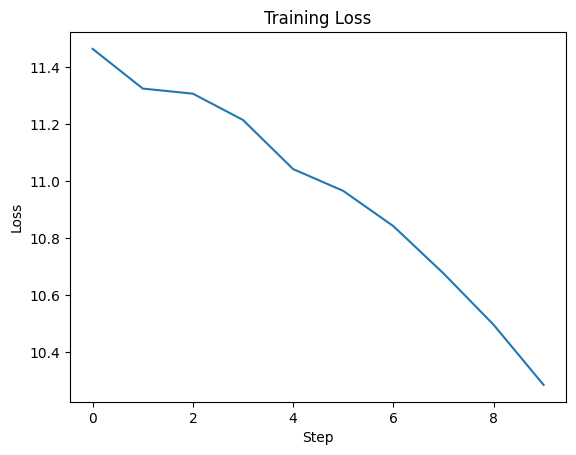

In [14]:
import matplotlib.pyplot as plt

# Training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 1
losses = []

print("Starting training...")
for epoch in range(epochs):
    # Just iterate over a few batches from our loader
    for i, batch in enumerate(loader):
        if i >= 10: # Just take 10 batches for a quick demo
            break
            
        input_ids = batch['input_ids'].to(device) if isinstance(batch, dict) else batch.to(device)
        
        # Typically for language modeling: inputs = targets shifted by 1
        inputs = input_ids[:, :-1]
        targets = input_ids[:, 1:]
        
        optimizer.zero_grad()
        logits = model(inputs)
        
        # Flatten for loss
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets.reshape(-1))
        
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        print(f"Batch {i}, Loss: {loss.item():.4f}")

plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()
